In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [29]:

# 1. Load and Explore Data
df = pd.read_csv('sonardataset.csv')
#describe
print(df.describe())

#info first 10
print(df.info())

#shape
print(df.shape)

#head
print(df.head())

#tail
print(df.tail())

# 2. Data Preprocessing
X = df.drop('Y', axis=1).values
y = df['Y'].values

# Encode Target ('M' -> 0, 'R' -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)






              x_1         x_2         x_3         x_4         x_5         x_6  \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.029164    0.038437    0.043832    0.053892    0.075202    0.104570   
std      0.022991    0.032960    0.038428    0.046528    0.055552    0.059105   
min      0.001500    0.000600    0.001500    0.005800    0.006700    0.010200   
25%      0.013350    0.016450    0.018950    0.024375    0.038050    0.067025   
50%      0.022800    0.030800    0.034300    0.044050    0.062500    0.092150   
75%      0.035550    0.047950    0.057950    0.064500    0.100275    0.134125   
max      0.137100    0.233900    0.305900    0.426400    0.401000    0.382300   

              x_7         x_8         x_9        x_10  ...        x_51  \
count  208.000000  208.000000  208.000000  208.000000  ...  208.000000   
mean     0.121747    0.134799    0.178003    0.208259  ...    0.016069   
std      0.061788    0.085152    0.118387    0.1

In [30]:
# 3. Model Implementation (Baseline)
def build_model(neurons=32, layers=1, activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(60,)))
    if layers == 2:
        model.add(Dense(neurons // 2, activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_model()
baseline_model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# 4. Hyperparameter Tuning (Simplified Grid Search)
best_acc = 0
best_params = {}
for n in [32, 64]:
    for act in ['relu', 'tanh']:
        for opt in ['adam', 'rmsprop']:
            model = build_model(neurons=n, activation=act, optimizer=opt)
            model.fit(X_train, y_train, epochs=30, batch_size=8, verbose=0)
            _, acc = model.evaluate(X_test, y_test, verbose=0)
            if acc > best_acc:
                best_acc = acc
                best_params = {'neurons': n, 'activation': act, 'optimizer': opt}

print(f"Best Params: {best_params}")

Best Params: {'neurons': 32, 'activation': 'relu', 'optimizer': 'adam'}


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Final Model Performance Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81        22
           1       0.82      0.70      0.76        20

    accuracy                           0.79        42
   macro avg       0.79      0.78      0.78        42
weighted avg       0.79      0.79      0.78        42



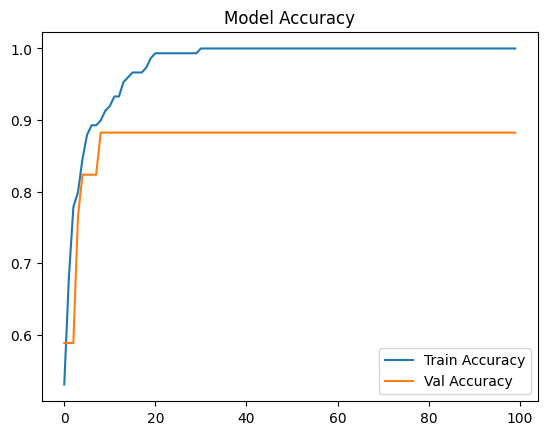

In [32]:
# 5. Final Tuned Model Evaluation
final_model = build_model(**best_params)
history = final_model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0, validation_split=0.1)

y_pred = (final_model.predict(X_test) > 0.5).astype(int)
print("\nFinal Model Performance Report:")
print(classification_report(y_test, y_pred))

# Plotting Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()